# AAV5 — Récupération des poids de Potts (viabilité + 3 sélectivités)

Régression d'un modèle de Potts (F additif + J pairwise, 8541 features : single-site one-hot
+ pairwise outer-product + biais) sur le **log2 enrichment réel** de chaque cible, à partir du
**CSV de travail** `AAV5_organoides_sorted.csv` (§5 de `AAV5_SEL_sorting.ipynb` :
`10 ≤ compte_plasmide ≤ 500`, variants à `hamming ≤ 2` du 7m8 retirés).

Même recette que `AAV9_potts_regression.ipynb` / `AAV5_SEL_analysis.ipynb` §3
(`RegressionV1.fit_weights_potts_from_data`). 4 cibles, un fit indépendant chacune :

| nom | cible (log2 enrichment) | dénominateur / numérateur (poids inverse-variance) |
|---|---|---|
| `viab`     | `log2_enrichissement_virus_sur_plasmide`       | plasmide / virus |
| `sel_org1` | `log2_enrichissement_organoide_1_adn_sur_virus`| virus / organoïde 1 adn |
| `sel_org2` | `log2_enrichissement_organoide_2_adn_sur_virus`| virus / organoïde 2 adn |
| `sel_org3` | `log2_enrichissement_organoide_3_adn_sur_virus`| virus / organoïde 3 adn |

`LAM = 0.0` (fit OLS minimum-norm, sans pénalité) par défaut : sur ces données la CV sur λ
tombe systématiquement sur des λ énormes (1e3–2e5) qui rétrécissent F/J vers la moyenne et
tuent le signal. Mettre `LAM = None` pour rebalayer la CV, `LAM = <x>` pour une ridge fixe.

Poids exportés dans `lib/aav5_{F,J}_{name}_potts_sorted_{tag}.npy` (gitignorés — données IDV
confidentielles ; suffixe `sorted_` pour ne pas écraser les `.npy` de `AAV5_SEL_analysis.ipynb`
qui fittent sur le CSV brut).

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# robust lib path: walk up to Modelization_V2/ (hardcoded ../../lib resolves to V1's pip copy)
_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "Modelization_V2")
sys.path.insert(0, str(_root / "lib"))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"   # before jax initializes (RegressionV1 imports jax)
LIB = _root / "lib"

import RegressionV1 as R
from analysisV1 import AA_LABELS, pearson, topk_recovery
assert "Modelization_V2" in R.__file__, R.__file__
print(R.message, "|", R.__file__)

CSV = Path("AAV5_organoides_sorted.csv")
if not CSV.exists():
    CSV = _root / "notebooks/notebooks/Selectivity/AAV5/AAV5_organoides_sorted.csv"
assert CSV.exists(), CSV

viab_col = "log2_enrichissement_virus_sur_plasmide"
sel_cols = [f"log2_enrichissement_organoide_{i}_adn_sur_virus" for i in (1, 2, 3)]
# name -> (target col, denominator count col, numerator count col)
targets = {
    "viab":     (viab_col,    "compte_plasmide", "compte_virus"),
    "sel_org1": (sel_cols[0], "compte_virus",    "compte_organoide_1_adn"),
    "sel_org2": (sel_cols[1], "compte_virus",    "compte_organoide_2_adn"),
    "sel_org3": (sel_cols[2], "compte_virus",    "compte_organoide_3_adn"),
}
use_cols = ["sequence"] + sorted({c for t in targets.values() for c in t})
dtypes = {"sequence": "string", **{c: "float32" for c in use_cols if c != "sequence"}}
df = pd.read_csv(CSV, usecols=use_cols, dtype=dtypes)
df["sequence"] = df["sequence"].astype("string")
print(df.shape)
df.head()

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


file regression 1.5 | /home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V2/lib/RegressionV1.py
(3822400, 10)


,sequence,compte_plasmide,compte_virus,log2_enrichissement_virus_sur_plasmide,compte_organoide_1_adn,log2_enrichissement_organoide_1_adn_sur_virus,compte_organoide_2_adn,log2_enrichissement_organoide_2_adn_sur_virus,compte_organoide_3_adn,log2_enrichissement_organoide_3_adn_sur_virus
0,TEVDRMT,36.5,0.5,-4.928953,0.0,NaN,0.0,NaN,0.0,NaN
1,TGRSDAQ,10.0,8.5,1.026406,0.0,NaN,0.0,NaN,0.0,NaN
2,PIRINSN,14.5,1.0,-2.597110,0.0,NaN,0.0,NaN,0.0,NaN
3,GNLRVIL,35.5,10.0,-0.566948,0.0,NaN,0.0,NaN,0.0,NaN
4,MNTEPRM,42.0,9.0,-0.961521,0.0,NaN,0.0,NaN,0.0,NaN


In [2]:
# encode the 7-mers once (same recipe as AAV9_potts_regression.ipynb)
assert list(AA_LABELS) == sorted(set("".join(df["sequence"].head(200_000))))
L, A = 7, 20

lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i
seq_matrix = lut[np.frombuffer("".join(df["sequence"]).encode("ascii"), np.uint8)].reshape(len(df), L)
print("seq_matrix:", seq_matrix.shape)


def score_FJ(seq, F, J):
    """F: (A, L)  J: (L, L, A, A)  ->  F_part + J_part per sequence (deterministic GT score)."""
    F, J = np.asarray(F), np.asarray(J)
    Fp = F[seq, np.arange(L)].sum(axis=1).astype(np.float64)
    Jp = np.zeros(len(seq), dtype=np.float64)
    for i in range(L):
        for j in range(i + 1, L):
            Jp += J[i, j, seq[:, i], seq[:, j]]
    return Fp + Jp

seq_matrix: (3822400, 7)


## 1. Fit

Un fit de Potts par cible. Poids d'observation `w = 1 / (1/n_num + 1/n_den)` (variance
approx. d'un log-ratio de comptages Poisson — sature au lieu d'exploser sur un variant
très profond). Split 50/50 `train_test_split(random_state=0)` ; fit sur ≤ `N_FIT` lignes,
évaluation held-out sur ≤ `N_EVAL` lignes disjointes. `r_deep` = Pearson sur le décile de
variants à lecture la plus profonde du held-out.

In [3]:
from sklearn.model_selection import train_test_split

LAM     = 0.0                     # None -> CV sur LAMBDAS ; 0.0 -> OLS minimum-norm ; >0 -> ridge fixe
LAMBDAS = np.logspace(-2, 6, 25)  # utilisé seulement si LAM is None
KFOLDS  = 3
N_FIT   = 80_000
N_EVAL  = 150_000
RNG     = np.random.default_rng(0)
WEIGHT_TAG = f"sorted_{'unreg' if LAM == 0 else (f'lam{LAM:g}' if LAM is not None else 'cv')}"
print(f"LAM = {LAM!r}   ->   fichiers de poids taggés '_{WEIGHT_TAG}'\n")

fits = {}
for name, (col, den_col, num_col) in targets.items():
    y_all = df[col].to_numpy(np.float64)
    c_den = df[den_col].to_numpy(np.float64)
    c_num = df[num_col].to_numpy(np.float64)
    w_all = 1.0 / (1.0 / (c_num + 0.5) + 1.0 / (c_den + 0.5))

    idx = np.flatnonzero(np.isfinite(y_all))
    y, S, w = y_all[idx], seq_matrix[idx], w_all[idx]
    eff_n = w.sum() ** 2 / (w ** 2).sum()          # Kish effective sample size

    tr, te = train_test_split(np.arange(len(idx)), test_size=0.5, random_state=0)
    fit_i  = tr if len(tr) <= N_FIT  else RNG.choice(tr, N_FIT,  replace=False)
    eval_i = te if len(te) <= N_EVAL else RNG.choice(te, N_EVAL, replace=False)

    F, J, rank, info = R.fit_weights_potts_from_data(
        S[fit_i], y[fit_i], sample_weight=w[fit_i],
        lambdas_grid=LAMBDAS, k_folds=KFOLDS, seed=0, verbose=False, lam=LAM)
    F, J = np.asarray(F), np.asarray(J)
    pred = score_FJ(S[eval_i], F, J)
    hi = w[eval_i] > np.quantile(w[eval_i], 0.90)

    fits[name] = dict(
        F=F, J=J, lam=info["lam"], rank=int(rank),
        cv_mse=np.asarray(info["cv_mse"]) if info["cv_mse"] is not None else None,
        lambdas=np.asarray(info["lambdas_grid"]) if info["lambdas_grid"] is not None else None,
        n_finite=len(idx), n_fit=len(fit_i), eff_n=eff_n, var_y=float(np.var(y[fit_i])),
        y_eval=y[eval_i], pred_eval=pred, w_eval=w[eval_i],
        r_all=pearson(y[eval_i], pred), r_deep=pearson(y[eval_i][hi], pred[hi]),
    )
    m = fits[name]
    print(f"{name:9s} n_finite={m['n_finite']:>9,}  eff_n={m['eff_n']:>9,.0f}  "
          f"lambda={m['lam']:.3g}  rank={m['rank']}/8541   "
          f"held-out r: all={m['r_all']:+.3f}  deep10%={m['r_deep']:+.3f}")

pd.DataFrame({k: {kk: v[kk] for kk in ("n_finite", "eff_n", "lam", "rank", "var_y", "r_all", "r_deep")}
              for k, v in fits.items()}).T

LAM = 0.0   ->   fichiers de poids taggés '_sorted_unreg'

viab      n_finite=3,822,400  eff_n=1,869,391  lambda=0  rank=4891/8541   held-out r: all=+0.204  deep10%=+0.129
sel_org1  n_finite=   78,719  eff_n=    4,772  lambda=0  rank=4842/8541   held-out r: all=+0.142  deep10%=+0.232
sel_org2  n_finite=  381,627  eff_n=   11,096  lambda=0  rank=4860/8541   held-out r: all=+0.399  deep10%=+0.662
sel_org3  n_finite=  179,341  eff_n=    9,071  lambda=0  rank=4856/8541   held-out r: all=+0.360  deep10%=+0.617


,n_finite,eff_n,lam,rank,var_y,r_all,r_deep
viab,3822400.0,1.869391e+06,0.0,4891.0,6.111921,0.204211,0.129471
sel_org1,78719.0,4.772187e+03,0.0,4842.0,20.582630,0.142469,0.231578
sel_org2,381627.0,1.109623e+04,0.0,4860.0,7.411090,0.399404,0.662393
sel_org3,179341.0,9.071190e+03,0.0,4856.0,9.125379,0.360457,0.616517


## 2. Diagnostic du fit

Ligne du haut : courbe CV MSE vs λ si un balayage a eu lieu (`LAM is None`), sinon rappel du λ
fixe + `Var(y)` (MSE d'un modèle constant). Ligne du bas : score GT (F + J) vs cible réelle sur
le held-out (hexbin log), diagonale blanche.

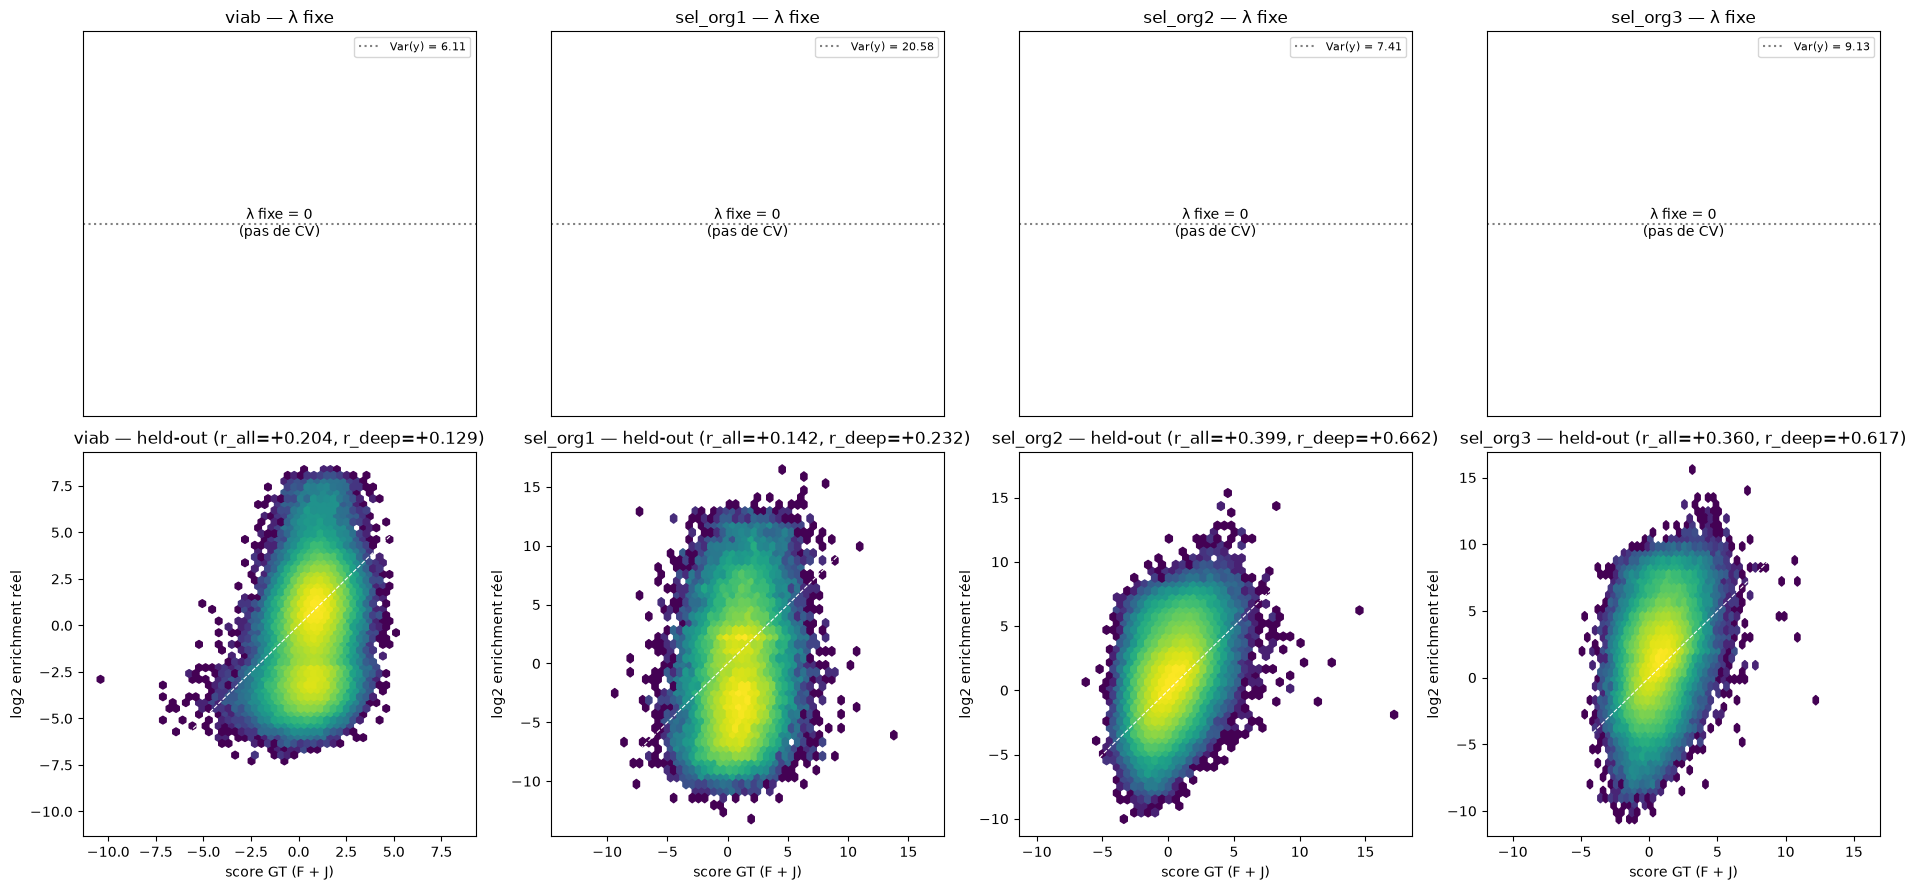

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(19, 9))
for k, (name, f) in enumerate(fits.items()):
    ax = axes[0, k]
    if f["cv_mse"] is not None:
        ax.plot(f["lambdas"], f["cv_mse"], "o-", ms=3)
        ax.axvline(f["lam"], color="crimson", ls="--", label=f"λ* = {f['lam']:.2g}")
        ax.set(xscale="log", title=f"{name} — CV MSE vs λ", xlabel="λ", ylabel="held-out MSE")
    else:
        ax.text(0.5, 0.5, f"λ fixe = {f['lam']:.3g}\n(pas de CV)", ha="center", va="center",
                transform=ax.transAxes)
        ax.set(title=f"{name} — λ fixe", xticks=[], yticks=[])
    ax.axhline(f["var_y"], color="grey", ls=":", label=f"Var(y) = {f['var_y']:.2f}")
    ax.legend(fontsize=8)

    ax = axes[1, k]
    p, yv = f["pred_eval"], f["y_eval"]
    ax.hexbin(p, yv, gridsize=45, bins="log", mincnt=1, cmap="viridis")
    lo, hi = min(p.min(), yv.min()), max(p.max(), yv.max())
    ax.plot([lo, hi], [lo, hi], "w--", lw=0.8)
    ax.set(title=f"{name} — held-out (r_all={f['r_all']:+.3f}, r_deep={f['r_deep']:+.3f})",
           xlabel="score GT (F + J)", ylabel="log2 enrichment réel")
plt.tight_layout(); plt.show()

## 3. Poids F (profil) et J (couplages)

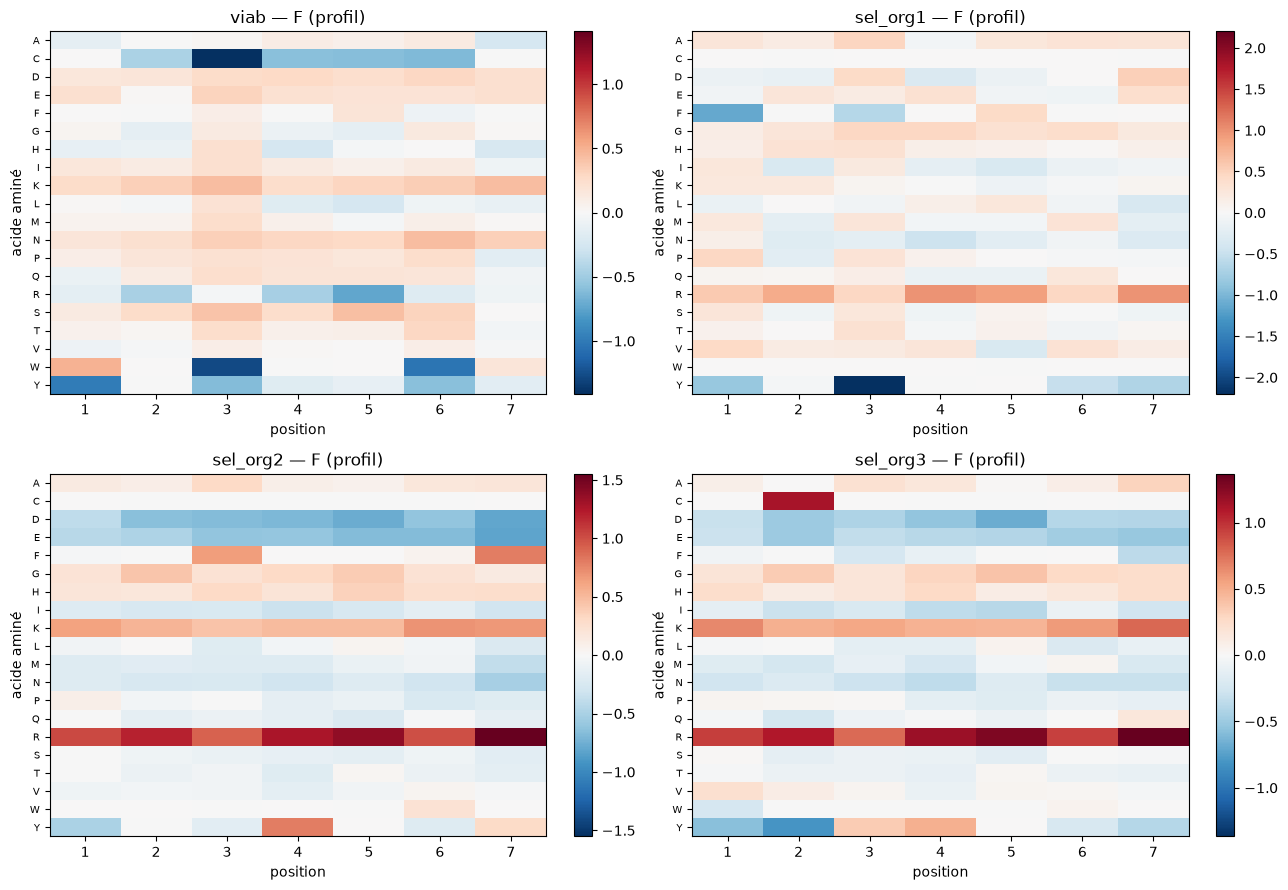

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (name, f) in zip(axes.ravel(), fits.items()):
    Fm = f["F"]                                   # (A, L)
    vmax = np.abs(Fm).max() or 1.0
    im = ax.imshow(Fm, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(L)); ax.set_xticklabels(range(1, L + 1))
    ax.set_yticks(range(A)); ax.set_yticklabels(AA_LABELS, fontsize=7)
    ax.set(title=f"{name} — F (profil)", xlabel="position", ylabel="acide aminé")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

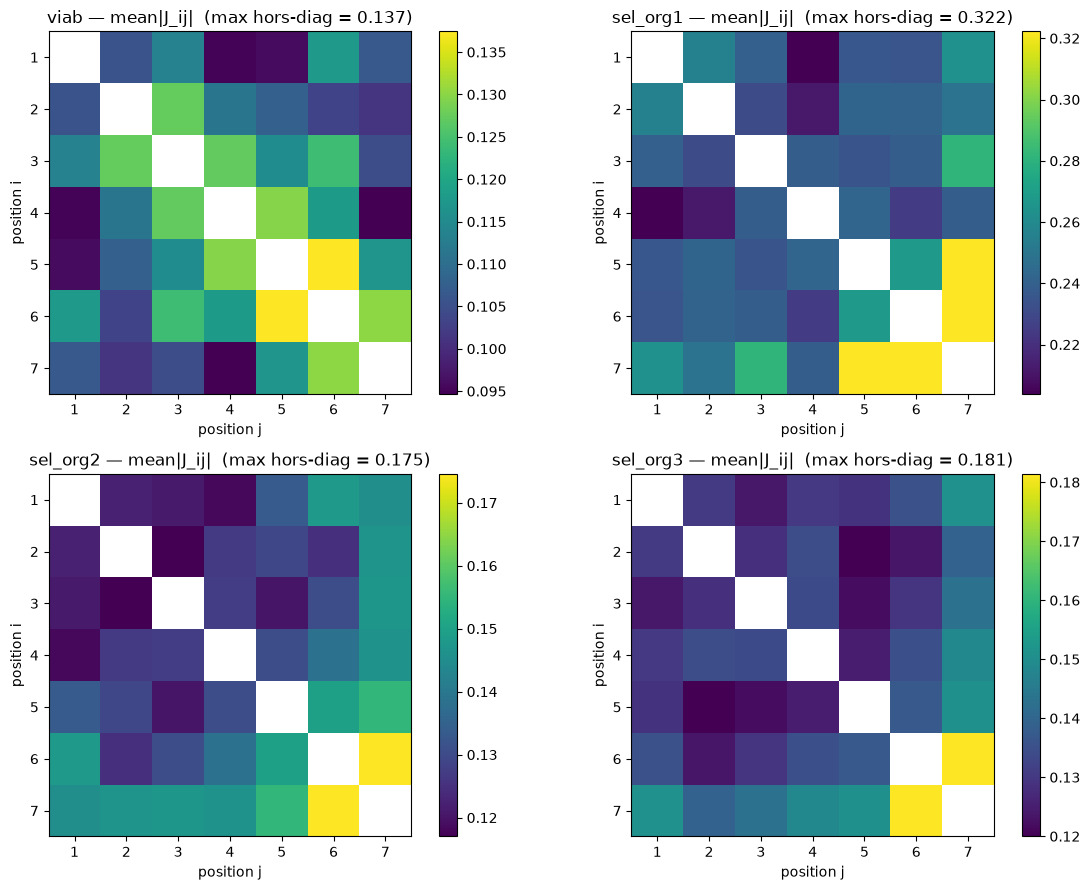

viab      mean|J|/mean|F| = 0.472   paires les + couplées : (5,6)=0.137, (6,7)=0.130, (4,5)=0.130, (2,3)=0.127
sel_org1  mean|J|/mean|F| = 0.940   paires les + couplées : (6,7)=0.322, (5,7)=0.322, (3,7)=0.281, (5,6)=0.268
sel_org2  mean|J|/mean|F| = 0.423   paires les + couplées : (6,7)=0.175, (5,7)=0.155, (5,6)=0.150, (1,6)=0.148
sel_org3  mean|J|/mean|F| = 0.472   paires les + couplées : (6,7)=0.181, (1,7)=0.151, (5,7)=0.151, (4,7)=0.149


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (name, f) in zip(axes.ravel(), fits.items()):
    Jabs = np.abs(f["J"]).mean(axis=(2, 3))       # (L, L) force de couplage moyenne |J_ij|
    off = Jabs.copy(); np.fill_diagonal(off, np.nan)
    im = ax.imshow(off, cmap="viridis")
    ax.set_xticks(range(L)); ax.set_xticklabels(range(1, L + 1))
    ax.set_yticks(range(L)); ax.set_yticklabels(range(1, L + 1))
    ax.set(title=f"{name} — mean|J_ij|  (max hors-diag = {np.nanmax(off):.3f})",
           xlabel="position j", ylabel="position i")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

for name, f in fits.items():
    Jabs = np.abs(f["J"]).mean(axis=(2, 3)); np.fill_diagonal(Jabs, 0.0)
    iu = np.triu_indices(L, 1)
    top = np.argsort(Jabs[iu])[::-1][:4]
    pairs = ", ".join(f"({iu[0][o]+1},{iu[1][o]+1})={Jabs[iu][o]:.3f}" for o in top)
    ratio = np.abs(f["J"]).mean() / (np.abs(f["F"]).mean() + 1e-12)
    print(f"{name:9s} mean|J|/mean|F| = {ratio:.3f}   paires les + couplées : {pairs}")

## 4. Distribution du score GT (F + J) sur la librairie de travail

`score_FJ` (déterministe, sans bruit protocole) sur les 3 822 400 variants du CSV de travail —
une GT par panneau. En surimpression : le sous-ensemble des variants dont la cible était
effectivement mesurée (fini).

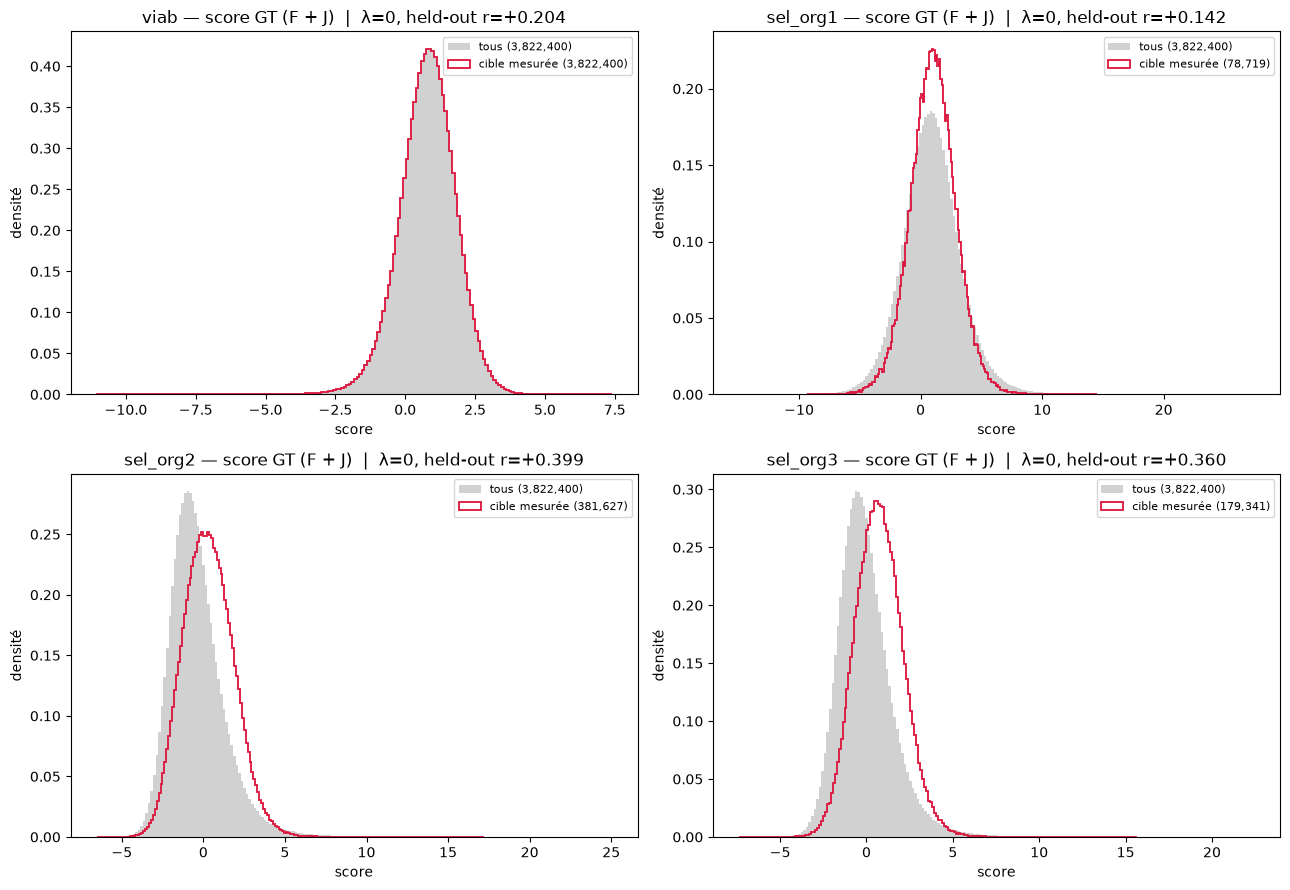

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (name, f) in zip(axes.ravel(), fits.items()):
    s = score_FJ(seq_matrix, f["F"], f["J"])
    f["score_full"] = s
    finite = np.isfinite(df[targets[name][0]].to_numpy())
    ax.hist(s, bins=200, density=True, color="0.82", label=f"tous ({s.size:,})")
    ax.hist(s[finite], bins=200, density=True, histtype="step", color="crimson", lw=1.3,
            label=f"cible mesurée ({int(finite.sum()):,})")
    ax.set(title=f"{name} — score GT (F + J)  |  λ={f['lam']:.2g}, held-out r={f['r_all']:+.3f}",
           xlabel="score", ylabel="densité")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Corrélations et régime de sélectivité

- `r(F_sel, F_viab)` / `r(J_sel, J_viab)` : la sélectivité est-elle corrélée / anticorrélée /
  indépendante de la viabilité (au niveau des poids) ?
- accord entre les 3 réplicats organoïde (plafond de reproductibilité).
- hexbin score GT sélectivité vs score GT viabilité sur la librairie : le régime au niveau
  du **paysage** (ce qui compte pour le design en aval).

F / J — sélectivité vs viabilité :
  sel_org1:  r(F) = +0.060   r(J) = -0.090
  sel_org2:  r(F) = -0.249   r(J) = -0.168
  sel_org3:  r(F) = -0.248   r(J) = -0.162

F / J — accord entre réplicats de sélectivité :
  sel_org1 vs sel_org2:  r(F) = +0.398   r(J) = +0.379
  sel_org1 vs sel_org3:  r(F) = +0.425   r(J) = +0.372
  sel_org2 vs sel_org3:  r(F) = +0.853   r(J) = +0.669


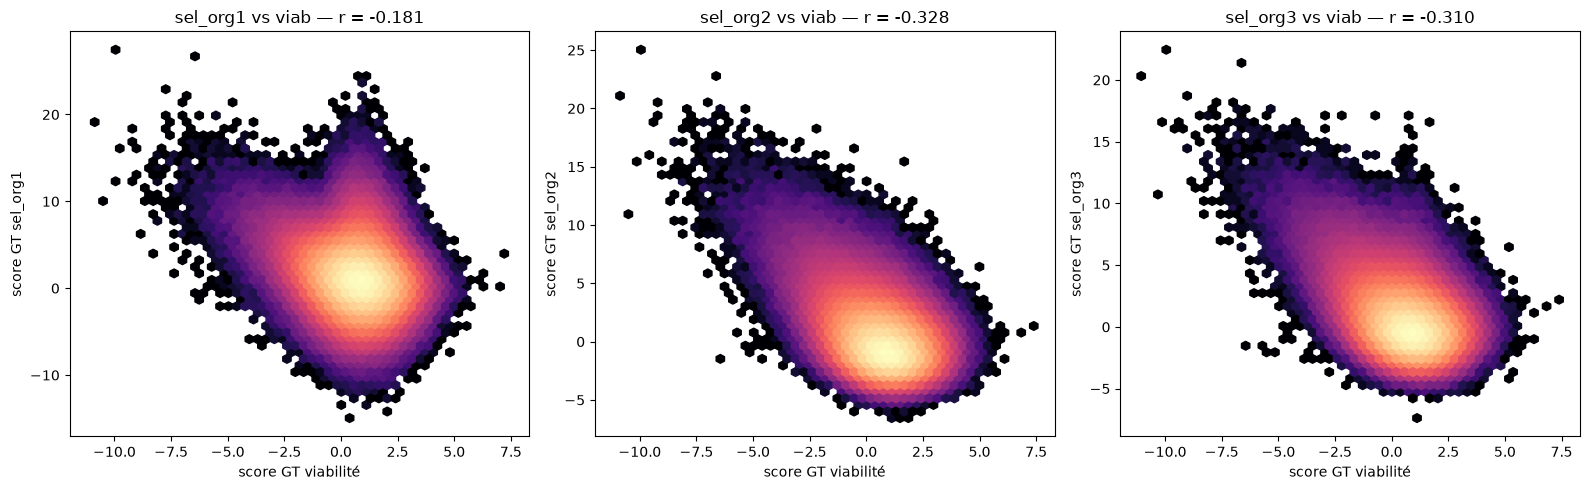

In [8]:
def corr(a, b):
    return np.corrcoef(np.asarray(a).ravel(), np.asarray(b).ravel())[0, 1]

print("F / J — sélectivité vs viabilité :")
for k in ("sel_org1", "sel_org2", "sel_org3"):
    print(f"  {k}:  r(F) = {corr(fits[k]['F'], fits['viab']['F']):+.3f}   "
          f"r(J) = {corr(fits[k]['J'], fits['viab']['J']):+.3f}")
print("\nF / J — accord entre réplicats de sélectivité :")
for a, b in [("sel_org1", "sel_org2"), ("sel_org1", "sel_org3"), ("sel_org2", "sel_org3")]:
    print(f"  {a} vs {b}:  r(F) = {corr(fits[a]['F'], fits[b]['F']):+.3f}   "
          f"r(J) = {corr(fits[a]['J'], fits[b]['J']):+.3f}")

sv = fits["viab"]["score_full"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, k in zip(axes, ("sel_org1", "sel_org2", "sel_org3")):
    ss = fits[k]["score_full"]
    ax.hexbin(sv, ss, gridsize=50, bins="log", mincnt=1, cmap="magma")
    ax.set(title=f"{k} vs viab — r = {corr(sv, ss):+.3f}",
           xlabel="score GT viabilité", ylabel=f"score GT {k}")
plt.tight_layout(); plt.show()

In [9]:
# recouvrement top-k entre réplicats de sélectivité (sur le paysage complet de la librairie)
rows = []
for k in (500, 5_000, 50_000):
    for a, b in [("sel_org1", "sel_org2"), ("sel_org1", "sel_org3"), ("sel_org2", "sel_org3")]:
        rows.append({"k": k, "paire": f"{a} ∩ {b}",
                     "recouvrement": round(topk_recovery(fits[a]["score_full"],
                                                          fits[b]["score_full"], k=k), 3)})
pd.DataFrame(rows).pivot(index="k", columns="paire", values="recouvrement")

paire,sel_org1 ∩ sel_org2,sel_org1 ∩ sel_org3,sel_org2 ∩ sel_org3
k,,,
500,0.184,0.216,0.734
5000,0.178,0.215,0.757
50000,0.204,0.247,0.747


## 6. Résidus held-out

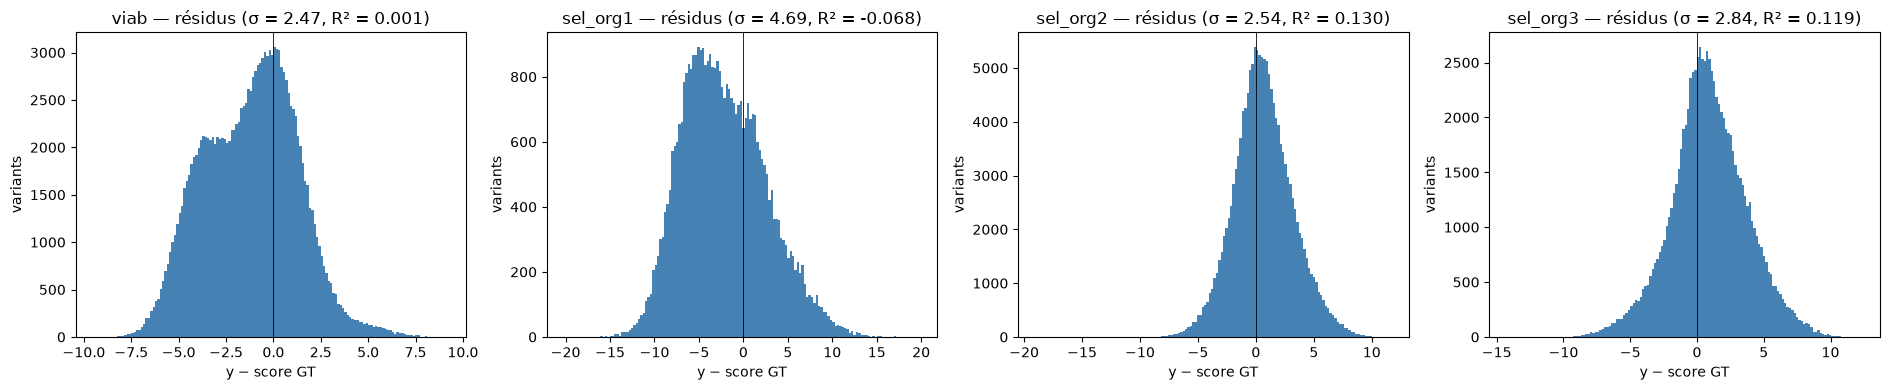

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4))
for ax, (name, f) in zip(axes, fits.items()):
    resid = f["y_eval"] - f["pred_eval"]
    ax.hist(resid, bins=150, color="steelblue")
    ax.axvline(0, color="k", lw=0.6)
    ax.set(title=f"{name} — résidus (σ = {resid.std():.2f}, "
                 f"R² = {1 - resid.var() / f['var_y']:.3f})",
           xlabel="y − score GT", ylabel="variants")
plt.tight_layout(); plt.show()

## 7. Export des poids

In [11]:
for name, f in fits.items():
    fp_F = LIB / f"aav5_F_{name}_potts_{WEIGHT_TAG}.npy"
    fp_J = LIB / f"aav5_J_{name}_potts_{WEIGHT_TAG}.npy"
    np.save(fp_F, np.asarray(f["F"], np.float32))
    np.save(fp_J, np.asarray(f["J"], np.float32))
    print(f"  {fp_F.name}   {fp_J.name}   (λ = {f['lam']:.3g}, held-out r = {f['r_all']:+.3f})")

  aav5_F_viab_potts_sorted_unreg.npy   aav5_J_viab_potts_sorted_unreg.npy   (λ = 0, held-out r = +0.204)
  aav5_F_sel_org1_potts_sorted_unreg.npy   aav5_J_sel_org1_potts_sorted_unreg.npy   (λ = 0, held-out r = +0.142)
  aav5_F_sel_org2_potts_sorted_unreg.npy   aav5_J_sel_org2_potts_sorted_unreg.npy   (λ = 0, held-out r = +0.399)
  aav5_F_sel_org3_potts_sorted_unreg.npy   aav5_J_sel_org3_potts_sorted_unreg.npy   (λ = 0, held-out r = +0.360)


# Partie 2 — Fit avec CV sur λ

La partie 1 utilise `LAM = 0.0` (OLS minimum-norm). Ici une **CV K-fold choisit λ** sur la
grille `LAMBDAS` (`np.logspace(-2, 6, 25)`), pour les 4 mêmes cibles et avec **exactement les
mêmes splits fit / held-out** que la partie 1 (`np.random.default_rng(0)` rejoué à l'identique)
— seule la régularisation change, la comparaison est directe.

⚠️ **Lent** : par cible, `KFOLDS` folds × (1 matrice de Gram 8541² + `len(LAMBDAS)` résolutions
8541³). Compter ~10–20 min par cible sur ce design 80k × 8541 (réduire `LAMBDAS` / `N_FIT_CV`
pour un premier passage).

Sorties : diagnostic CV (courbes MSE vs λ + hexbin held-out), comparaison λ=0 vs CV
(r held-out, r(F)/r(J) entre les deux jeux de poids, histogrammes de score superposés),
export `lib/aav5_{F,J}_{name}_potts_sorted_cv.npy`.


In [12]:
## 8. Fit CV — 4 cibles

LAMBDAS_CV = LAMBDAS              # même grille qu'en partie 1 (np.logspace(-2, 6, 25))
KFOLDS_CV  = KFOLDS
N_FIT_CV   = N_FIT               # mêmes splits que la partie 1 -> baisser ici change le sous-échantillon
RNG_CV     = np.random.default_rng(0)   # rejoue exactement la séquence de tirages de la partie 1

fits_cv = {}
for name, (col, den_col, num_col) in targets.items():
    y_all = df[col].to_numpy(np.float64)
    c_den = df[den_col].to_numpy(np.float64)
    c_num = df[num_col].to_numpy(np.float64)
    w_all = 1.0 / (1.0 / (c_num + 0.5) + 1.0 / (c_den + 0.5))

    idx = np.flatnonzero(np.isfinite(y_all))
    y, S, w = y_all[idx], seq_matrix[idx], w_all[idx]

    tr, te = train_test_split(np.arange(len(idx)), test_size=0.5, random_state=0)
    fit_i  = tr if len(tr) <= N_FIT_CV else RNG_CV.choice(tr, N_FIT_CV, replace=False)
    eval_i = te if len(te) <= N_EVAL  else RNG_CV.choice(te, N_EVAL,  replace=False)

    F, J, rank, info = R.fit_weights_potts_from_data(
        S[fit_i], y[fit_i], sample_weight=w[fit_i],
        lambdas_grid=LAMBDAS_CV, k_folds=KFOLDS_CV, seed=0, verbose=True, lam=None)
    F, J = np.asarray(F), np.asarray(J)
    pred = score_FJ(S[eval_i], F, J)
    hi = w[eval_i] > np.quantile(w[eval_i], 0.90)

    fits_cv[name] = dict(
        F=F, J=J, lam=info["lam"], rank=int(rank),
        cv_mse=np.asarray(info["cv_mse"]), lambdas=np.asarray(info["lambdas_grid"]),
        var_y=float(np.var(y[fit_i])),
        y_eval=y[eval_i], pred_eval=pred, w_eval=w[eval_i],
        r_all=pearson(y[eval_i], pred), r_deep=pearson(y[eval_i][hi], pred[hi]),
    )
    m = fits_cv[name]
    edge = "  <-- λ AU BORD DE GRILLE" if m["lam"] in (LAMBDAS_CV[0], LAMBDAS_CV[-1]) else ""
    print(f"{name:9s} λ*={m['lam']:.4g}  rank={m['rank']}/8541   "
          f"held-out r: all={m['r_all']:+.3f}  deep10%={m['r_deep']:+.3f}{edge}")

pd.DataFrame({k: {kk: v[kk] for kk in ("lam", "rank", "var_y", "r_all", "r_deep")}
              for k, v in fits_cv.items()}).T


Design matrix rank: 4891 / 8541 features (80000 obs)
  NOTE: rank-deficient design (p > n) -- ridge is not just a preference, the unregularized fit below is non-unique.


Best lambda: 1000.0000
viab      λ*=1000  rank=4891/8541   held-out r: all=+0.217  deep10%=+0.149
Design matrix rank: 4842 / 8541 features (39359 obs)
  NOTE: rank-deficient design (p > n) -- ridge is not just a preference, the unregularized fit below is non-unique.


Best lambda: 46415.8883
sel_org1  λ*=4.642e+04  rank=4842/8541   held-out r: all=+0.216  deep10%=+0.380
Design matrix rank: 4860 / 8541 features (80000 obs)
  NOTE: rank-deficient design (p > n) -- ridge is not just a preference, the unregularized fit below is non-unique.


Best lambda: 21544.3469
sel_org2  λ*=2.154e+04  rank=4860/8541   held-out r: all=+0.406  deep10%=+0.685
Design matrix rank: 4856 / 8541 features (80000 obs)
  NOTE: rank-deficient design (p > n) -- ridge is not just a preference, the unregularized fit below is non-unique.


Best lambda: 21544.3469
sel_org3  λ*=2.154e+04  rank=4856/8541   held-out r: all=+0.361  deep10%=+0.628


,lam,rank,var_y,r_all,r_deep
viab,1000.000000,4891.0,6.111921,0.217389,0.149423
sel_org1,46415.888336,4842.0,20.582630,0.216377,0.379596
sel_org2,21544.346900,4860.0,7.411090,0.406348,0.685008
sel_org3,21544.346900,4856.0,9.125379,0.361409,0.628066


## 9. Diagnostic du fit CV

Courbe CV MSE vs λ (ligne pointillée = `Var(y)`, MSE d'un modèle constant ; si la courbe
décroît de façon monotone jusqu'au bord de grille, la CV dit qu'aucun signal per-variant ne
généralise et rétrécit tout vers la moyenne). En bas : score GT vs cible réelle held-out.


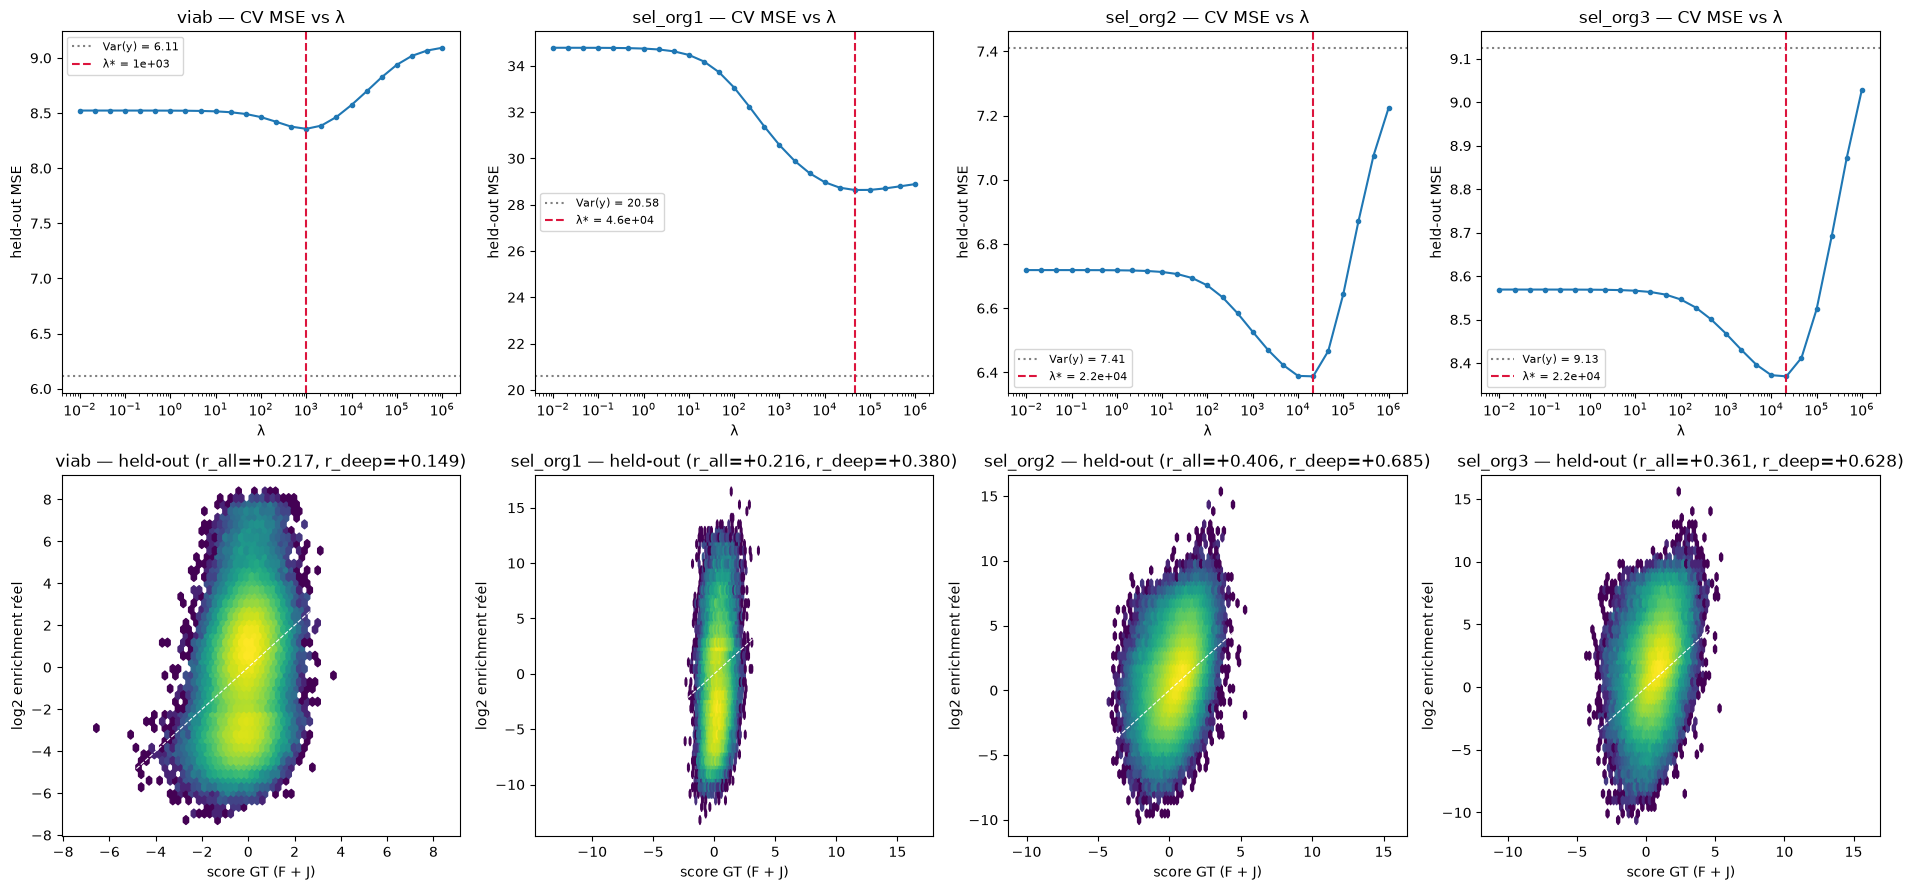

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(19, 9))
for k, (name, f) in enumerate(fits_cv.items()):
    ax = axes[0, k]
    ax.plot(f["lambdas"], f["cv_mse"], "o-", ms=3)
    ax.axhline(f["var_y"], color="grey", ls=":", label=f"Var(y) = {f['var_y']:.2f}")
    ax.axvline(f["lam"], color="crimson", ls="--", label=f"λ* = {f['lam']:.2g}")
    mono = np.all(np.diff(f["cv_mse"]) <= 1e-9)
    ax.set(xscale="log", title=f"{name} — CV MSE vs λ" + ("  (monotone ↓)" if mono else ""),
           xlabel="λ", ylabel="held-out MSE")
    ax.legend(fontsize=8)

    ax = axes[1, k]
    p, yv = f["pred_eval"], f["y_eval"]
    ax.hexbin(p, yv, gridsize=45, bins="log", mincnt=1, cmap="viridis")
    lo, hi = min(p.min(), yv.min()), max(p.max(), yv.max())
    ax.plot([lo, hi], [lo, hi], "w--", lw=0.8)
    ax.set(title=f"{name} — held-out (r_all={f['r_all']:+.3f}, r_deep={f['r_deep']:+.3f})",
           xlabel="score GT (F + J)", ylabel="log2 enrichment réel")
plt.tight_layout(); plt.show()


## 10. Comparaison λ = 0 (partie 1) vs CV

- `r held-out` : la CV fait-elle mieux / pareil / moins bien que l'OLS non régularisé ?
- `r(F, F_cv)` / `r(J, J_cv)` : à quel point la ridge choisie par CV a rétréci les poids
  (proche de 1 = peu d'effet ; proche de 0 = poids très différents).
- `r(score_λ0, score_cv)` : impact sur le **classement** des variants (ce qui compte pour le design).


In [14]:
def corr(a, b):
    return np.corrcoef(np.asarray(a).ravel(), np.asarray(b).ravel())[0, 1]

rows = []
for name in targets:
    f0, fc = fits[name], fits_cv[name]
    s0 = f0.get("score_full")
    if s0 is None:
        s0 = score_FJ(seq_matrix, f0["F"], f0["J"]); f0["score_full"] = s0
    sc = score_FJ(seq_matrix, fc["F"], fc["J"]); fc["score_full"] = sc
    rows.append({
        "cible": name,
        "lam0_r": round(f0["r_all"], 3), "cv_r": round(fc["r_all"], 3),
        "lam0_r_deep": round(f0["r_deep"], 3), "cv_r_deep": round(fc["r_deep"], 3),
        "cv_lambda": float(f"{fc['lam']:.4g}"),
        "r(F,F_cv)": round(corr(f0["F"], fc["F"]), 3),
        "r(J,J_cv)": round(corr(f0["J"], fc["J"]), 3),
        "r(score)": round(corr(s0, sc), 3),
        "topk500_∩": round(topk_recovery(s0, sc, k=500), 3),
    })
pd.DataFrame(rows).set_index("cible")


,lam0_r,cv_r,lam0_r_deep,cv_r_deep,cv_lambda,"r(F,F_cv)","r(J,J_cv)",r(score),topk500_∩
cible,,,,,,,,,
viab,0.204,0.217,0.129,0.149,1000.0,0.563,0.857,0.974,0.612
sel_org1,0.142,0.216,0.232,0.380,46420.0,0.497,0.511,0.389,0.102
sel_org2,0.399,0.406,0.662,0.685,21540.0,0.918,0.666,0.775,0.604
sel_org3,0.360,0.361,0.617,0.628,21540.0,0.854,0.696,0.722,0.576


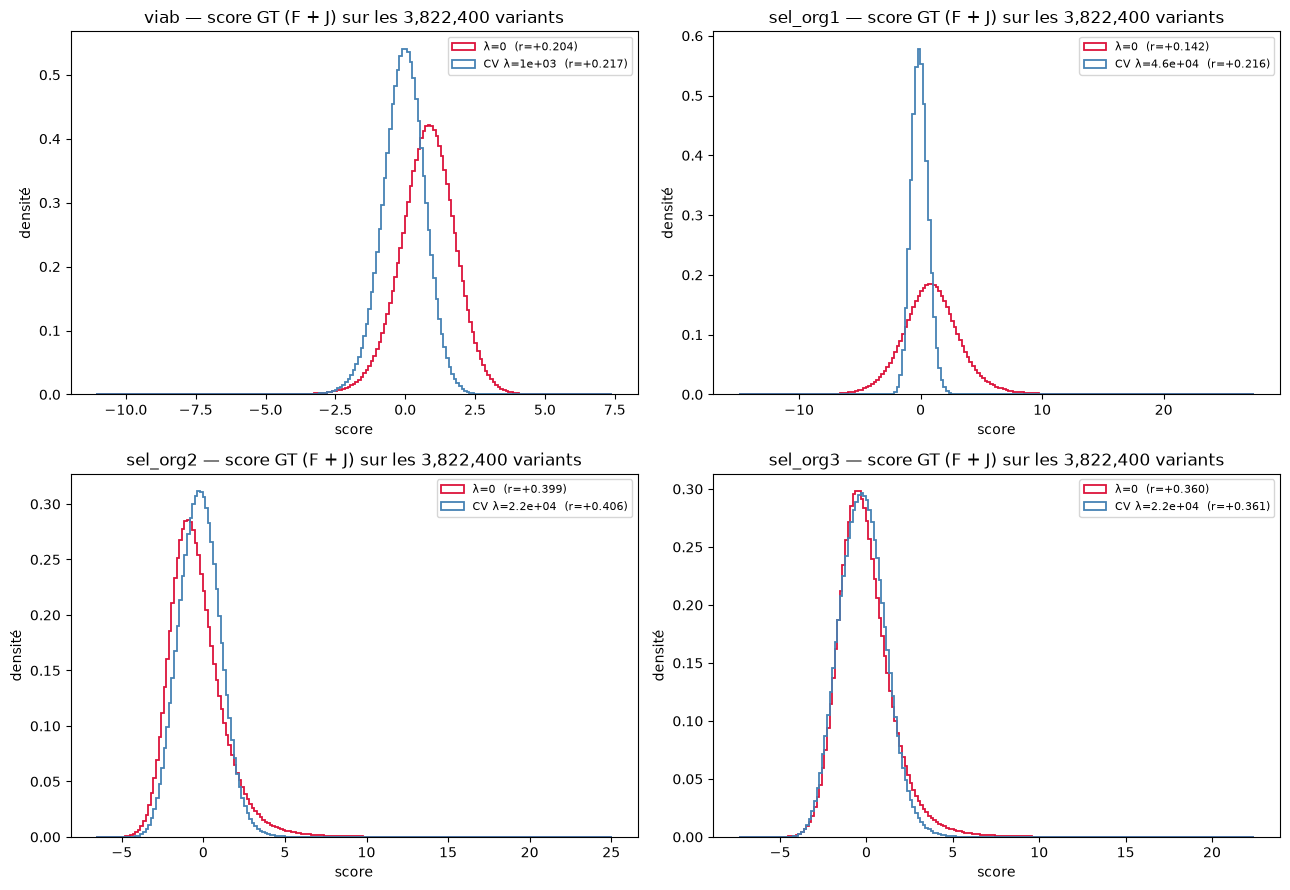

In [15]:
# histogrammes du score GT sur la librairie : λ=0 (partie 1) vs CV, superposés
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, name in zip(axes.ravel(), targets):
    s0, sc = fits[name]["score_full"], fits_cv[name]["score_full"]
    bins = np.linspace(min(s0.min(), sc.min()), max(s0.max(), sc.max()), 200)
    ax.hist(s0, bins=bins, density=True, histtype="step", color="crimson", lw=1.3,
            label=f"λ=0  (r={fits[name]['r_all']:+.3f})")
    ax.hist(sc, bins=bins, density=True, histtype="step", color="steelblue", lw=1.3,
            label=f"CV λ={fits_cv[name]['lam']:.2g}  (r={fits_cv[name]['r_all']:+.3f})")
    ax.set(title=f"{name} — score GT (F + J) sur les {s0.size:,} variants",
           xlabel="score", ylabel="densité")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 11. Export des poids CV


In [16]:
for name, f in fits_cv.items():
    fp_F = LIB / f"aav5_F_{name}_potts_sorted_cv.npy"
    fp_J = LIB / f"aav5_J_{name}_potts_sorted_cv.npy"
    np.save(fp_F, np.asarray(f["F"], np.float32))
    np.save(fp_J, np.asarray(f["J"], np.float32))
    print(f"  {fp_F.name}   {fp_J.name}   (λ = {f['lam']:.4g}, held-out r = {f['r_all']:+.3f})")


  aav5_F_viab_potts_sorted_cv.npy   aav5_J_viab_potts_sorted_cv.npy   (λ = 1000, held-out r = +0.217)
  aav5_F_sel_org1_potts_sorted_cv.npy   aav5_J_sel_org1_potts_sorted_cv.npy   (λ = 4.642e+04, held-out r = +0.216)
  aav5_F_sel_org2_potts_sorted_cv.npy   aav5_J_sel_org2_potts_sorted_cv.npy   (λ = 2.154e+04, held-out r = +0.406)
  aav5_F_sel_org3_potts_sorted_cv.npy   aav5_J_sel_org3_potts_sorted_cv.npy   (λ = 2.154e+04, held-out r = +0.361)
